In [1]:
#Lab 6:Exercise 1
# import libraries
import requests
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

In [10]:
url = "https://api.glasgow.gov.uk/traffic/v1/movement/sites"
def get_data(url):
    response = requests.get(url)
    # Check if the request was successful (status code 200)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: Failed to fetch data. Status code: {response.status_code}")
        return None

In [11]:
traffic = get_data(url)
traffic[0]

{'siteId': 'GH020A_B',
 'from': {'description': 'Gallowgate west to Sword St',
  'lat': '55.8543754827825',
  'long': '-4.217259197086495'},
 'to': {'description': 'Gallowgate west to Sword St',
  'lat': '55.854434529999814',
  'long': '-4.216974959509279'}}

In [14]:
# Convert the rerutned data from dict to dataframe
def dict_to_dataframe(data, coord_type="from"):
    data_dict = {}
    data_dict["siteId"] = [each_record["siteId"] for each_record in data]
    data_dict["lat"] = [each_record[coord_type]["lat"] for each_record in data]
    data_dict["long"] = [each_record[coord_type]["long"] for each_record in data]
    data_df = pd.DataFrame.from_dict(data_dict)
    return data_df

traffic_df = dict_to_dataframe(traffic, coord_type="from")
traffic_df = traffic_df.sort_values(by=['siteId']).reset_index(drop=True)
traffic_df

,siteId,lat,long
0,DD1701_A,55.89207133579384,-4.38950253308813
1,DD1701_B,55.89009089504372,-4.383175384174624
2,DD1701_C,55.89198288109072,-4.3866501574123875
3,GA0100_S,55.85684166248406,-4.265400511332697
4,GA0101_D,55.85670943385504,-4.273542113352281
...,...,...,...
1270,GL4101_B,55.86454009498399,-4.334828688523635
1271,GL4101_T,55.864941248072974,-4.337841527417336
1272,GL4151_B,55.86590847266791,-4.339913527626766
1273,GL4151_C,55.86533300965921,-4.339926860074516


In [58]:
# Create a GeoDataFrame
traffic_df["geometry"] = gpd.points_from_xy(traffic_df["long"], traffic_df["lat"])
# Set coordinate reference system
traffic_gdf = gpd.GeoDataFrame(traffic_df, crs="epsg:4326")
# Reproject
traffic_gdf_4326 = traffic_gdf.copy()
traffic_gdf_3857 = traffic_gdf.to_crs("EPSG:3857")

In [ ]:
# Fliter the sensors via locations
borough_uk = gpd.read_file("data/district_borough_unitary.shp")
borough_uk = borough_uk.set_crs("EPSG:27700", allow_override=True)

borough_gla = borough_uk.loc[borough_uk['Name'].str.contains('Glasgow City', case=False)].copy()
borough_gla_4326 = borough_gla.to_crs("EPSG:4326")

traffic_join = gpd.sjoin(
    traffic_gdf_4326, 
    borough_gla_4326, 
    how='inner', 
    predicate='intersects'
)

traffic_join_3857 = traffic_join.to_crs("EPSG:3857")

修正后格拉斯哥传感器数量： 1201


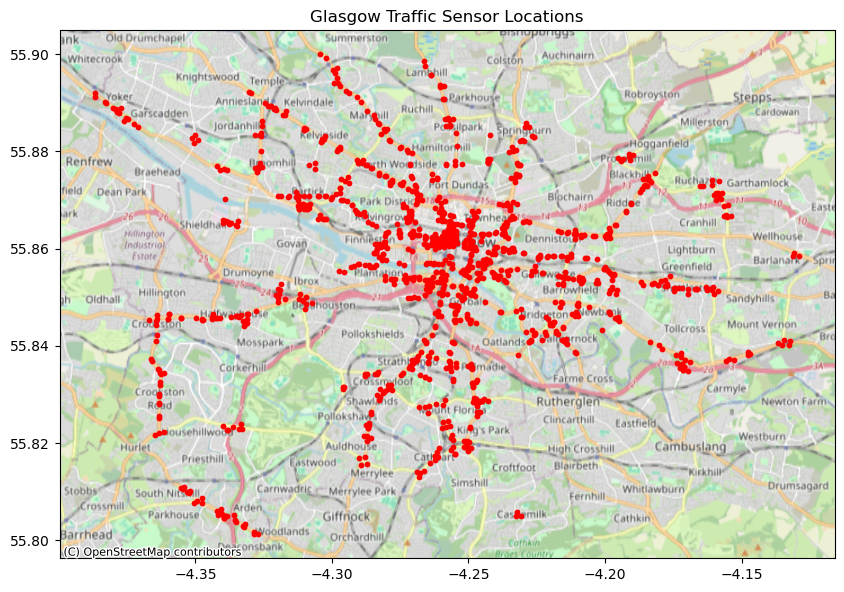

In [63]:
fig, ax = plt.subplots(figsize=(10, 10))

traffic_join.plot(ax=ax, color='red', markersize=10)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    crs=traffic_join.crs
)

plt.title("Glasgow Traffic Sensor Locations")
plt.show()


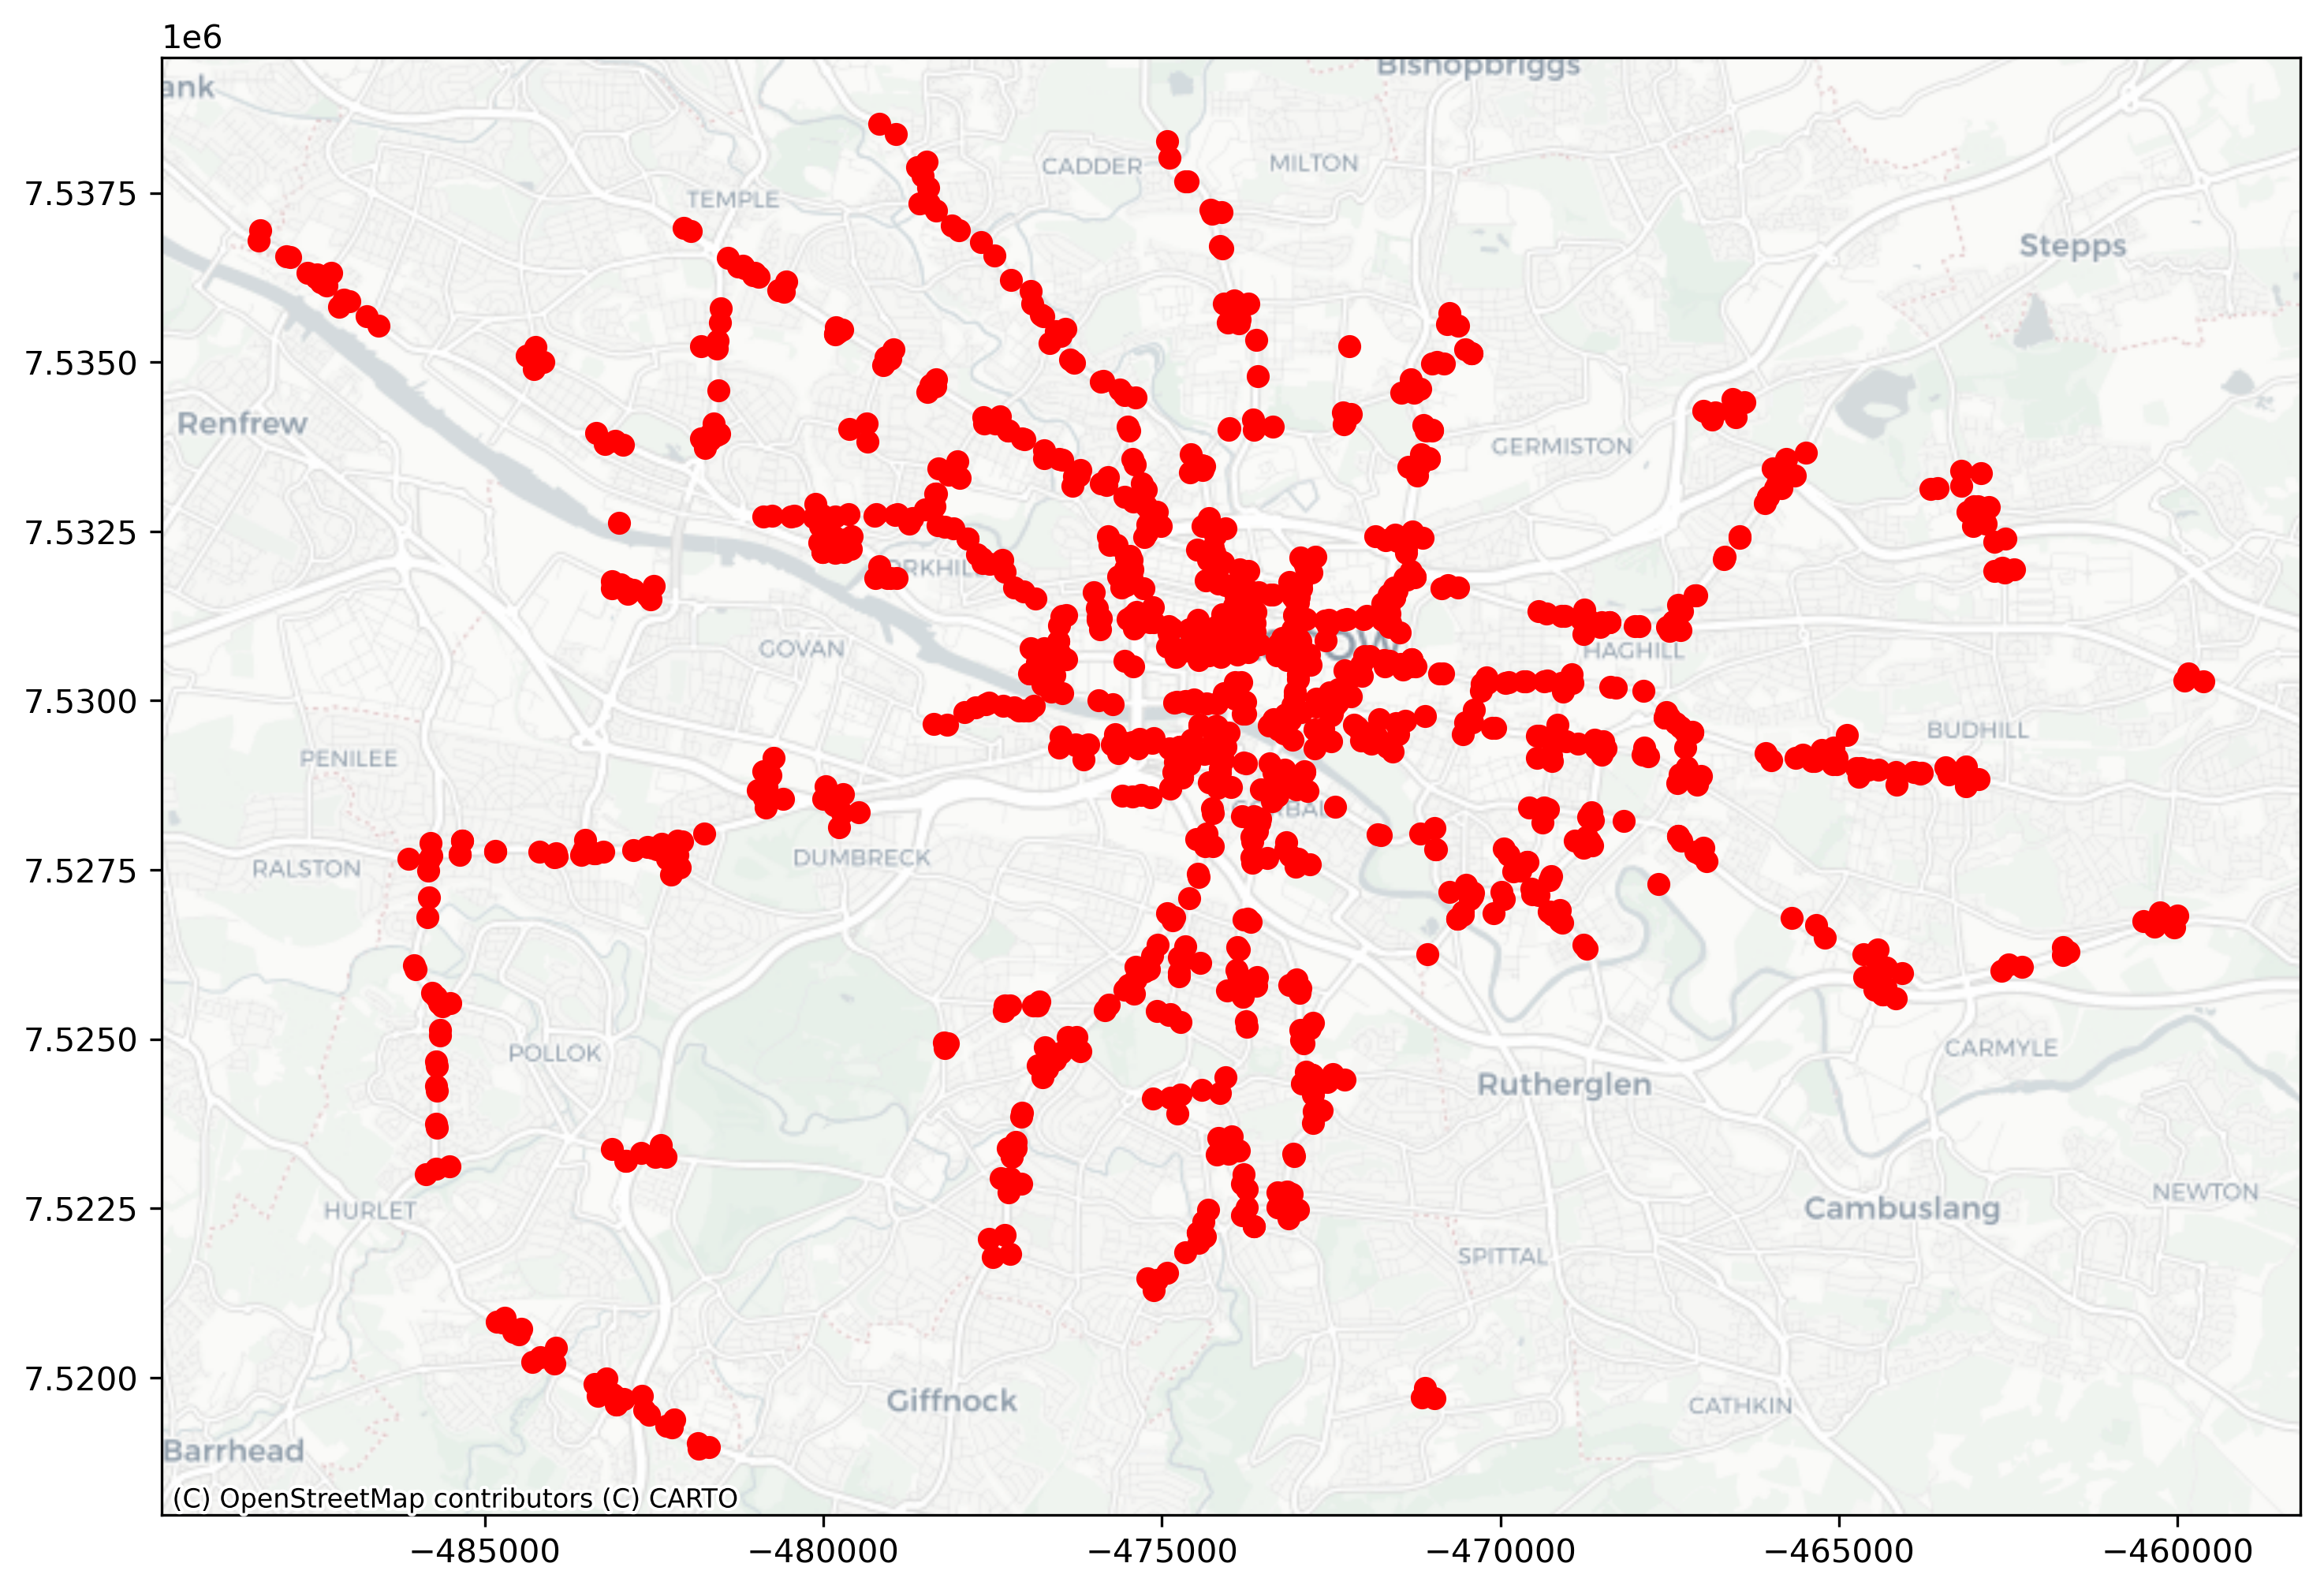

In [66]:
fig, ax = plt.subplots(figsize=(12,8), dpi=300) 
#Plot the data
traffic_join_3857.plot(color = 'red',ax=ax)
#Add basemap
ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)

In [ ]:

print(borough_gla['Name'].values[0])

Glasgow City


In [65]:
# interactive map
traffic_join.explore(column='siteId', tooltip='siteId', popup=True)